## Import Modules

In [ ]:
import pandas as pd
import numpy as np
import time
import os
import copy
import json

# visualization modules
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image

# pytorch modules
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import torchvision.transforms as transforms

#for augmentation
import albumentations
from albumentations.pytorch.transforms import ToTensorV2

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

## Load Dataset

In [ ]:
BASE_DIR = "../input/cassava-leaf-disease-classification/"

train = pd.read_csv(BASE_DIR+'train.csv')
train.head()

,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


In [ ]:
# Print the number of unique classes
print(train['label'].nunique())

5


In [ ]:
# Loading mapping of labels
with open(BASE_DIR+'label_num_to_disease_map.json') as f:
    mapping = json.loads(f.read())
    mapping = {int(k): v for k, v in mapping.items()}
mapping

{0: 'Cassava Bacterial Blight (CBB)',
 1: 'Cassava Brown Streak Disease (CBSD)',
 2: 'Cassava Green Mottle (CGM)',
 3: 'Cassava Mosaic Disease (CMD)',
 4: 'Healthy'}

In [ ]:
train['label_names'] = train['label'].map(mapping)
train.head()

,image_id,label,label_names
0,1000015157.jpg,0,Cassava Bacterial Blight (CBB)
1,1000201771.jpg,3,Cassava Mosaic Disease (CMD)
2,100042118.jpg,1,Cassava Brown Streak Disease (CBSD)
3,1000723321.jpg,1,Cassava Brown Streak Disease (CBSD)
4,1000812911.jpg,3,Cassava Mosaic Disease (CMD)


## Exploratory Data Analysis

In [ ]:
def plot_images(class_id, label, total_images=6):
    # get image ids corresponding to the target class id
    plot_list = train[train['label']==class_id].sample(total_images)['image_id'].tolist()

    labels = [label for i in range(total_images)]
    # dynamically set size for subplot
    size = int(np.sqrt(total_images))
    if size*size < total_images:
        size += 1

    # set figure size
    plt.figure(figsize=(15,15))

    # plot the image in subplot
    for index, (image_id, label) in enumerate(zip(plot_list, labels)):
        plt.subplot(size, size, index+1)
        image = Image.open(str(BASE_DIR+'train_images/'+image_id))
        print(image.size)
        plt.imshow(image)
        plt.title(label, fontsize=14)
        plt.axis('off')

    plt.show()

(800, 600)
(800, 600)
(800, 600)
(800, 600)
(800, 600)
(800, 600)


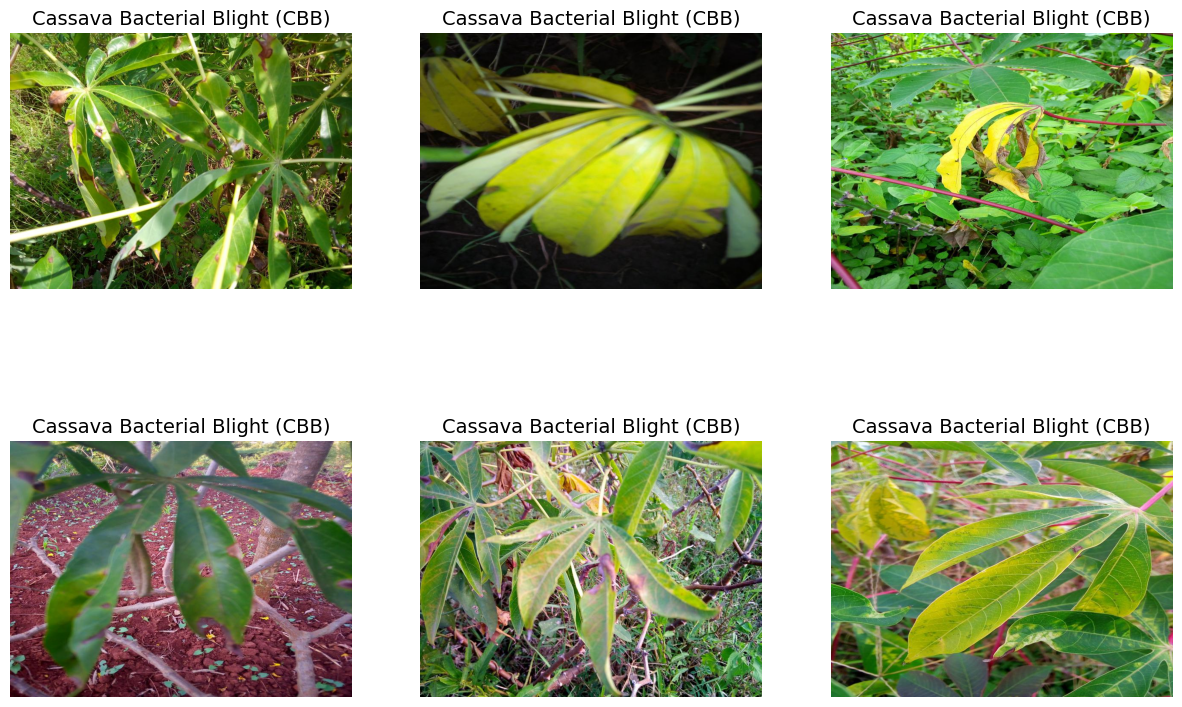

In [ ]:
plot_images(0, mapping[0], 6)  #I want to know the resolution of original images

(800, 600)
(800, 600)
(800, 600)
(800, 600)
(800, 600)
(800, 600)


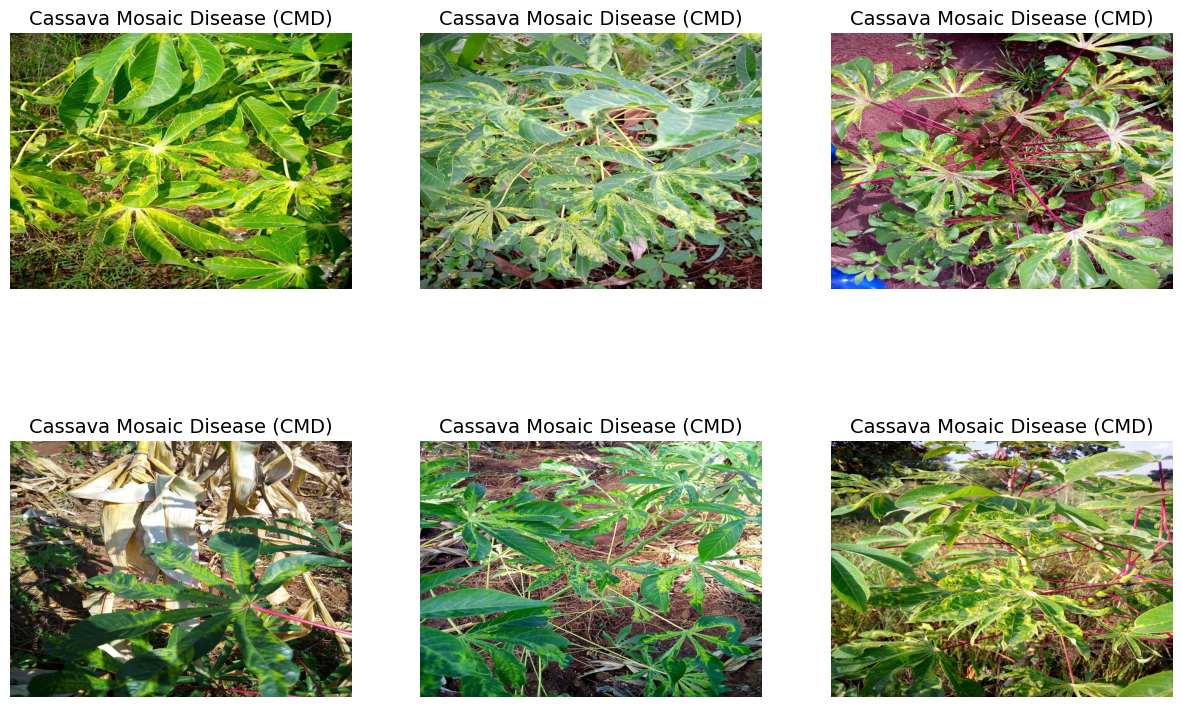

In [ ]:
plot_images(3, mapping[3], 6)

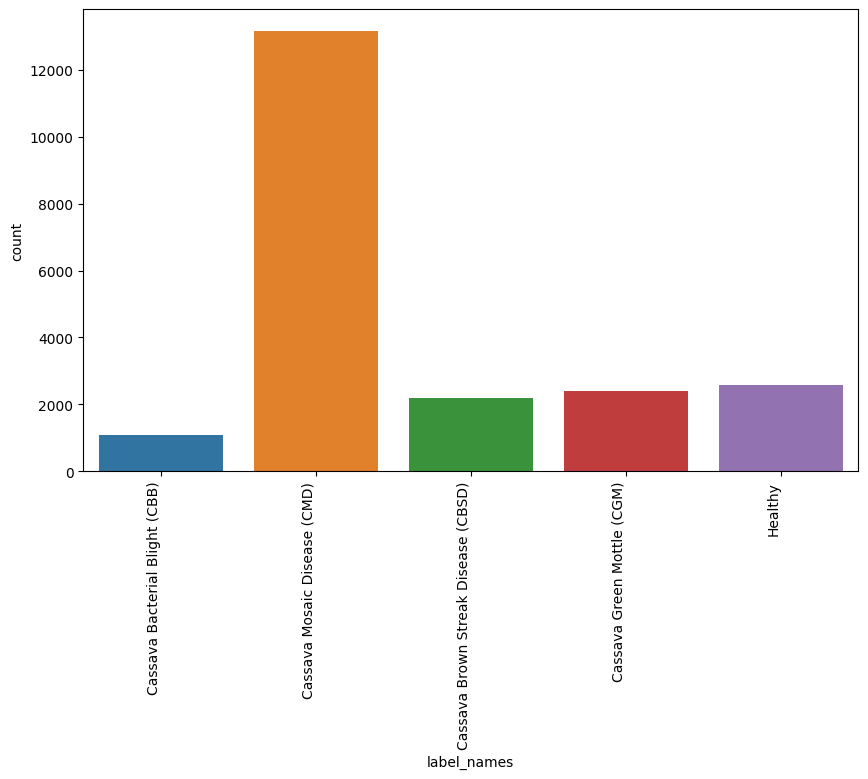

In [ ]:
# class distribution
plt.figure(figsize=(10, 6))
ax = sns.countplot(x=train['label_names'])
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')
plt.show()

## Adjust Configurations

In [ ]:
DIM = (256, 256) #to reduce the resolution of the image
WIDTH, HEIGHT = DIM
NUM_CLASSES = 5
NUM_WORKERS = 24
TRAIN_BATCH_SIZE = 16
VAL_BATCH_SIZE = 16
TEST_BATCH_SIZE = 16
SEED = 1

DEVICE = 'cuda'

MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

## Augmentation

In [ ]:
def get_test_transforms(value = 'val'):
    if value == 'train':
        return albumentations.Compose([
            albumentations.Resize(WIDTH, HEIGHT),

            # GEOMETRIC ENHANCEMENTS
            albumentations.ShiftScaleRotate(
                shift_limit=0.0625, scale_limit=0.1, rotate_limit=30, p=0.7
            ), # Replaces the basic Rotate
            albumentations.HorizontalFlip(p=0.5),
            albumentations.VerticalFlip(p=0.5),
            albumentations.CoarseDropout(max_holes=8, max_height=8, max_width=8, p=0.1),

            # COLOR/LIGHT ENHANCEMENTS
            albumentations.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.8),
            albumentations.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),

            # BLUR/NOISE
            albumentations.GaussNoise(p=0.2),

            # Normalization
            albumentations.Normalize(MEAN, STD, max_pixel_value=255.0, always_apply=True),
            ToTensorV2(p=1.0)
        ])
    elif value == 'val': # this is for Val and Test
        return albumentations.Compose([
            albumentations.Resize(WIDTH, HEIGHT),
            albumentations.Normalize(MEAN, STD, max_pixel_value=255.0, always_apply=True),
            ToTensorV2(p=1.0)
        ])

## Creating Class for Dataset Loader

In [ ]:
class CassavaDataset(Dataset):
    def __init__(self, image_ids, labels, dimension=None, augmentations=None, folder='train_images'):
        super().__init__()
        self.image_ids = image_ids
        self.labels = labels
        self.dim = dimension
        self.augmentations = augmentations
        self.folder = folder

    # returns the length
    def __len__(self):
        return len(self.image_ids)

    # return the image and label for that index
    def __getitem__(self, idx):
        img = Image.open(os.path.join(BASE_DIR, self.folder, self.image_ids[idx]))

        if self.dim:
            img = img.resize(self.dim)

        # convert to numpy array
        img = np.array(img)

        if self.augmentations:
            augmented = self.augmentations(image=img)
            img = augmented['image']

        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label

## Split 70% train, 20% validation and 10% test

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np #for the split calculation

# Temporary Training Set (90%) and the Final Test Set (10%)
X_temp, X_test, y_temp, y_test = train_test_split(
    train['image_id'],
    train['label'],
    test_size=0.10, # Sets aside the 10% for the Test set
    random_state=42
)

# the required test_size for this split is (0.20 / 0.90) ≈ 0.22
validation_size_ratio = 0.20 / (1 - 0.10)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=validation_size_ratio, # Sets aside the 20% for the Validation set
    random_state=42
)
# X_train is 70%, X_val is 20%, and X_test is 10%.

## Creating Dataloaders

In [ ]:
from torch.utils.data import WeightedRandomSampler

def sampler_(labels):
    label_unique, counts = np.unique(labels, return_counts=True)
    print('Unique Labels', label_unique)
    weights = [sum(counts) / c for c in counts]
    sample_weights = [weights[w] for w in labels]  #This calculation ensures that rare classes get a higher weight
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)
    return sampler

train_sampler = sampler_(y_train)

Unique Labels [0 1 2 3 4]


In [ ]:
train_dataset = CassavaDataset(
    image_ids=X_train.values,
    labels=y_train.values,
    augmentations=get_test_transforms('train'),
    dimension=DIM
)

train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=True,
    sampler=train_sampler
)

val_dataset = CassavaDataset(
    image_ids=X_val.values,
    labels=y_val.values,
    augmentations=get_test_transforms('val'),
    dimension=DIM
)

val_loader = DataLoader(
    val_dataset,
    batch_size=VAL_BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=False
)

test_dataset = CassavaDataset(
    image_ids=X_test.values,
    labels=y_test.values,
    augmentations=get_test_transforms('val'),
    dimension=DIM
)

test_loader = DataLoader(
    test_dataset,
    batch_size=TEST_BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=False
)

loaders = {'train': train_loader, 'val': val_loader}

## Using Pretrained Model

In [ ]:
def getModel():
    net = models.resnet152(pretrained=True)

    for param in net.parameters():
        param.requires_grad = False

    num_ftrs = net.fc.in_features

    # to create last few layers
    net.fc = nn.Sequential(
        nn.Linear(num_ftrs, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, NUM_CLASSES),
        # nn.LogSoftmax(dim=1)
    )

    # use gpu if exits
    net = net.cuda() if DEVICE else net
    return net

In [ ]:
model = getModel()

Downloading: "https://download.pytorch.org/models/resnet152-394f9c45.pth" to /root/.cache/torch/hub/checkpoints/resnet152-394f9c45.pth
100%|██████████| 230M/230M [00:01<00:00, 196MB/s] 


## Cyclical Learning Rates

In [ ]:
import math  #we used CLR as a trial to improve accuracy
def cyclical_lr(stepsize, min_lr=3e-4, max_lr=3e-3):

    # Scaler: we can adapt this if we do not want the triangular CLR
    scaler = lambda x: 1.

    # Lambda function to calculate the LR
    lr_lambda = lambda it: min_lr + (max_lr - min_lr) * relative(it, stepsize)

    # this function to see where on the cycle we are
    def relative(it, stepsize):
        cycle = math.floor(1 + it / (2 * stepsize))
        x = abs(it / stepsize - 2 * cycle + 1)
        return max(0, (1 - x)) * scaler(cycle)

    return lr_lambda

In [ ]:
criterion = nn.CrossEntropyLoss()

# optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
optimizer = torch.optim.SGD(model.parameters(), lr=1, momentum=0.9)

step_size = 4*len(train_loader)
# clr = cyclical_lr(step_size, min_lr=3e-4, max_lr=3e-3) #the old range
clr = cyclical_lr(step_size, min_lr=1e-5, max_lr=3e-4) #the new range
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, [clr])

In [ ]:
# print(model)

In [ ]:
unfreeze = True # this was a trial to improve accuracy, this to update all model weights according our datasets (fine tuning)
for param in model.parameters():
    param.requires_grad = unfreeze

In [ ]:
# to see total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print(f'{total_params:,} total parameters')
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'{trainable_params:,} training parameters')

58,669,637 total parameters
58,669,637 training parameters


## Training and Validation Phase

In [ ]:
def train_model(model, dataloaders, criterion, optimizer, num_epochs=5, scheduler=scheduler):
    # set starting time
    start_time = time.time()

    val_acc_history = []

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs-1}')
        print('-'*15)

        # each epoch have training and validation phase
        for phase in ['train', 'val']:
            # set mode for model
            if phase == 'train':
                model.train() # set model to training mode
            else:
                model.eval() # set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0
            fin_out = []

            # iterate over data
            for inputs, labels in dataloaders[phase]:
                # move data to corresponding hardware
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)

                # reset the parameter gradients
                optimizer.zero_grad()

                # training or validation process
                with torch.set_grad_enabled(phase=='train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    _, preds = torch.max(outputs, 1)

                    # back propagation in the network
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                        scheduler.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            # calculate loss and accuarcy for the epoch
            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            # print loss and acc for training & validation
            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

            # update the best weights
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
            if phase == 'val':
                val_acc_history.append(epoch_acc)

        print()
    end_time = time.time() - start_time

    print('Training completes in {:.0f}m {:.0f}s'.format(end_time // 60, end_time % 60))
    print('Best Val Acc: {:.4f}'.format(best_acc))

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model, val_acc_history

In [ ]:
# train the model
model, accuracy = train_model(model=model, dataloaders=loaders, criterion=criterion, optimizer=optimizer, num_epochs=15, scheduler=scheduler)
# changing number of epocs to 15 instead of 5 as a trial to improve accuracy

Epoch 0/14
---------------
train Loss: 1.5980 Acc: 0.2426
val Loss: 1.5493 Acc: 0.4143

Epoch 1/14
---------------
train Loss: 1.4572 Acc: 0.4009
val Loss: 1.1250 Acc: 0.6610

Epoch 2/14
---------------
train Loss: 1.1698 Acc: 0.5316
val Loss: 0.8863 Acc: 0.6743

Epoch 3/14
---------------
train Loss: 1.0042 Acc: 0.6122
val Loss: 0.7282 Acc: 0.7348

Epoch 4/14
---------------
train Loss: 0.8929 Acc: 0.6564
val Loss: 0.6964 Acc: 0.7526

Epoch 5/14
---------------
train Loss: 0.8381 Acc: 0.6796
val Loss: 0.7280 Acc: 0.7402

Epoch 6/14
---------------
train Loss: 0.7779 Acc: 0.7069
val Loss: 0.5594 Acc: 0.8005

Epoch 7/14
---------------
train Loss: 0.7816 Acc: 0.7042
val Loss: 0.6479 Acc: 0.7629

Epoch 8/14
---------------
train Loss: 0.7542 Acc: 0.7095
val Loss: 0.6647 Acc: 0.7565

Epoch 9/14
---------------
train Loss: 0.7441 Acc: 0.7218
val Loss: 0.6079 Acc: 0.7815

Epoch 10/14
---------------
train Loss: 0.7373 Acc: 0.7239
val Loss: 0.5813 Acc: 0.7890

Epoch 11/14
---------------
tra

In [ ]:
# save the model and model weights
torch.save(model, '/kaggle/working/best_model_trial2.h5')
torch.save(model.state_dict(), '/kaggle/working/best_model_weights_trial2')

## Testing Phase

In [ ]:
# empty the cache from cuda device to free memory
torch.cuda.empty_cache()

In [ ]:
def test_model(model, dataloader):
    # Set model to evaluation mode
    model.eval()
    running_corrects = 0

    for inputs, labels in dataloader:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)

        with torch.no_grad(): # for testing
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

        running_corrects += torch.sum(preds == labels.data)

    test_acc = running_corrects.double() / len(dataloader.dataset)
    print('Final Test Acc: {:.4f}'.format(test_acc))

test_model(model, test_loader)

Final Test Acc: 0.8229
